<a href="https://colab.research.google.com/github/ogc1231/mole_classification_deep_learning/blob/main/Deepl_Learning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# install kaggle
!pip install kaggle

In [2]:
# upload kaggle API key, kaggle.json
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ogc1231","key":"9ad0f56f60f271638145976c763f3e2e"}'}

In [3]:
# get and set kaggle credentials
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from PIL import Image
import random
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

In [5]:
DATA_DIR = "./HAM10000"
ZIP_FILE = os.path.join(DATA_DIR, "skin-cancer-mnist-ham10000.zip")

# Make sure the folder exists
os.makedirs(DATA_DIR, exist_ok=True)

# Download the dataset if ZIP is missing
if not os.path.exists(ZIP_FILE):
    !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p {DATA_DIR}

# Split dataset into two folder, paths to folders
IMG_DIR_1 = os.path.join(DATA_DIR, "HAM10000_images_part_1")
IMG_DIR_2 = os.path.join(DATA_DIR, "HAM10000_images_part_2")

# Unzip only if images are not found
if not (os.path.exists(IMG_DIR_1) and os.path.exists(IMG_DIR_2)):
    !unzip -q {ZIP_FILE} -d {DATA_DIR}


Dataset URL: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
License(s): CC-BY-NC-SA-4.0
100% 5.20G/5.20G [01:51<00:00, 87.2MB/s]
100% 5.20G/5.20G [01:51<00:00, 50.0MB/s]


In [9]:
# Get metadata from images classes
meta_path = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

# Load CSV
meta = pd.read_csv(meta_path)

# Quick check
print(meta.head())

     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


Folder 1 exists: True
Folder 2 exists: True
Images in part 1: 5000
Images in part 2: 5015
Total images: 10015


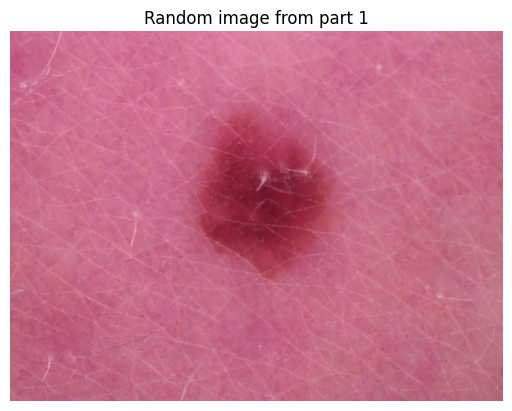

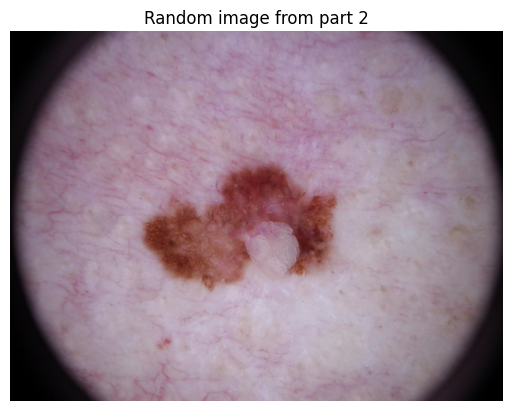

Testing image ID: ISIC_0025697
Class label: nv
Found in: ./HAM10000/HAM10000_images_part_1/ISIC_0025697.jpg


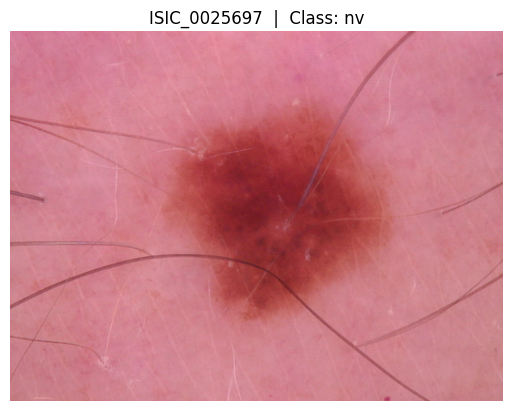

In [10]:
print("Folder 1 exists:", os.path.exists(IMG_DIR_1))
print("Folder 2 exists:", os.path.exists(IMG_DIR_2))

imgs1 = [f for f in os.listdir(IMG_DIR_1) if f.endswith(".jpg")]
imgs2 = [f for f in os.listdir(IMG_DIR_2) if f.endswith(".jpg")]

print("Images in part 1:", len(imgs1))
print("Images in part 2:", len(imgs2))
print("Total images:", len(imgs1) + len(imgs2))

# Random from part 1
img1_path = os.path.join(IMG_DIR_1, random.choice(imgs1))
img1 = Image.open(img1_path)

plt.imshow(img1)
plt.title("Random image from part 1")
plt.axis('off')
plt.show()

# Random from part 2
img2_path = os.path.join(IMG_DIR_2, random.choice(imgs2))
img2 = Image.open(img2_path)

plt.imshow(img2)
plt.title("Random image from part 2")
plt.axis('off')
plt.show()

# Pick a random row from the metadata
row = meta.sample(1).iloc[0]

image_id = row["image_id"]          # filename (without .jpg)
dx_label = row["dx"]                # class label

print("Testing image ID:", image_id)
print("Class label:", dx_label)

# Build paths
p1 = os.path.join(IMG_DIR_1, image_id + ".jpg")
p2 = os.path.join(IMG_DIR_2, image_id + ".jpg")

# Select correct path
path = p1 if os.path.exists(p1) else p2
print("Found in:", path)

# Display the image
img = Image.open(path)
plt.imshow(img)
plt.title(f"{image_id}  |  Class: {dx_label}")
plt.axis("off")
plt.show()
